

#Contexte du Projet
-----
L'objectif de ce projet est d'explorer différents modèles de régression et de classification afin de détecter les fraudes à partir d'un jeu de données fourni spécifiquement par mon professeur.

Nous appliquerons plusieurs méthodes d'analyse et comparerons les performances des modèles pour tirer des conclusions sur leur efficacité.

Ce projet s'inscrit dans le cadre de mon stage au laboratoire ERIC de l'Université Lyon Lumière 2, réalisé durant ma deuxième année de licence, sous l'encadrement de Monsieur Mickaël Lallouche.

              id  step      type      amount     nameOrig  oldbalanceOrg  \
0              1     1   PAYMENT     9839.64  C1231006815      170136.00   
1              2     1   PAYMENT     1864.28  C1666544295       21249.00   
2              5     1   PAYMENT    11668.14  C2048537720       41554.00   
3              7     1   PAYMENT     7107.77   C154988899      183195.00   
4              8     1   PAYMENT     7861.64  C1912850431      176087.23   
...          ...   ...       ...         ...          ...            ...   
4262951  6362612   742  CASH_OUT    63416.99   C994950684       63416.99   
4262952  6362614   743  CASH_OUT  1258818.82  C1436118706     1258818.82   
4262953  6362617   743  TRANSFER  6311409.28  C1529008245     6311409.28   
4262954  6362618   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
4262955  6362620   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0     

<Axes: xlabel='oldbalanceOrg', ylabel='amount'>

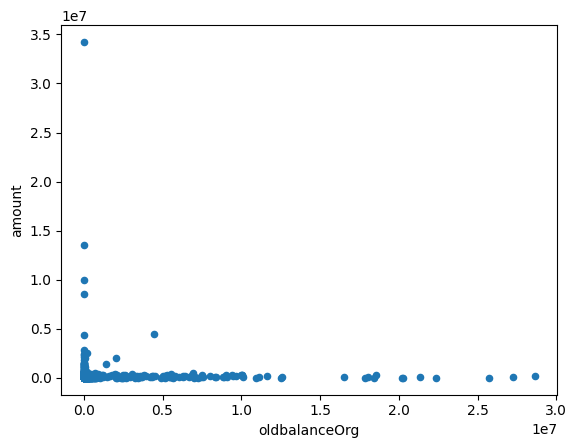

In [ ]:
import numpy as np
import pandas as pd
Données_bancaire_train=pd.DataFrame(pd.read_csv('train.csv'))
print(Données_bancaire_train)
Données_bancaire_train.sample(1000).plot(kind='scatter',x='oldbalanceOrg',y='amount')


In [ ]:
Données_bancaire_train.info()
Données_bancaire_train.groupby('type').count()
#5 types de payements différents
#CASH_OUT,CASH_IN	,DEBIT,TRANSFER,PAYMENT

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4262956 entries, 0 to 4262955
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   step            int64  
 2   type            object 
 3   amount          float64
 4   nameOrig        object 
 5   oldbalanceOrg   float64
 6   newbalanceOrig  float64
 7   nameDest        object 
 8   oldbalanceDest  float64
 9   newbalanceDest  float64
 10  isFraud         int64  
 11  isFlaggedFraud  int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 390.3+ MB


,id,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
type,,,,,,,,,,,
CASH_IN,936724,936724,936724,936724,936724,936724,936724,936724,936724,936724,936724
CASH_OUT,1499584,1499584,1499584,1499584,1499584,1499584,1499584,1499584,1499584,1499584,1499584
DEBIT,27666,27666,27666,27666,27666,27666,27666,27666,27666,27666,27666
PAYMENT,1441731,1441731,1441731,1441731,1441731,1441731,1441731,1441731,1441731,1441731,1441731
TRANSFER,357251,357251,357251,357251,357251,357251,357251,357251,357251,357251,357251


#Heatmap
---

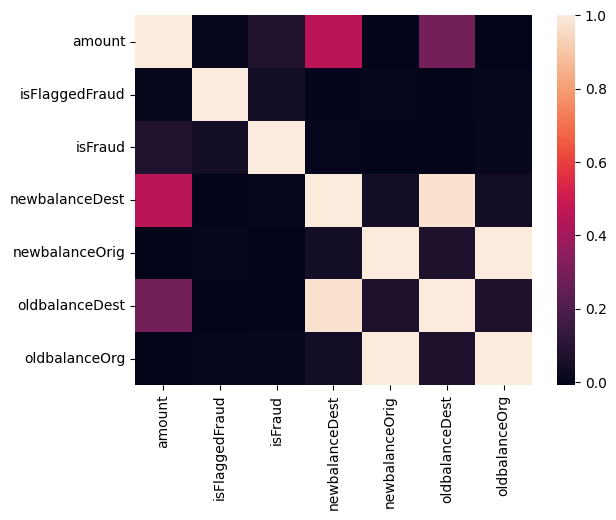

In [ ]:
#Evaluation de la correlation entre les variables
import seaborn as sns
import matplotlib.pyplot as plt
Données_bancaire_train=Données_bancaire_train[Données_bancaire_train.columns.difference(['type','id','step','nameOrig','nameDest'])]
sns.heatmap(Données_bancaire_train.corr())
plt.show()

In [ ]:
y=Données_bancaire_train.isFraud #Variable à expliquer
y.groupby(y).count()# sur tout le train data set on a 5552 fraud
X=Données_bancaire_train.drop(columns=['isFraud'])
#X=X[X.columns.difference(['type','id','step','nameOrig','nameDest'])]
X

#import seaborn as sns
#sns.heatmap(X.corr())


,amount,isFlaggedFraud,newbalanceDest,newbalanceOrig,oldbalanceDest,oldbalanceOrg
0,9839.64,0,0.00,160296.36,0.00,170136.00
1,1864.28,0,0.00,19384.72,0.00,21249.00
2,11668.14,0,0.00,29885.86,0.00,41554.00
3,7107.77,0,0.00,176087.23,0.00,183195.00
4,7861.64,0,0.00,168225.59,0.00,176087.23
...,...,...,...,...,...,...
4262951,63416.99,0,339850.17,0.00,276433.18,63416.99
4262952,1258818.82,0,1762283.33,0.00,503464.50,1258818.82
4262953,6311409.28,0,0.00,0.00,0.00,6311409.28
4262954,6311409.28,0,6379898.11,0.00,68488.84,6311409.28


Afin d'évaluer la performance et la capacité de généralisation de notre modèle, nous devons sélectionner l'un des algorithmes de machine learning. Nous l'entraînerons sur l'ensemble de données d'apprentissage, puis nous testerons son efficacité sur l'ensemble de données réservé au test.

##Nettoyage et adaptation des Données
----

## Arbre de decision
---

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)
X_test=pd.DataFrame(pd.read_csv('test.csv'))
Y_test=X_test.isFraud
X_test=X_test[X_test.columns.difference(['type','isFraud','id','step','nameOrig','nameDest'])]
Y_pred=clf.predict(X_test)




from sklearn.metrics import accuracy_score, recall_score ,f1_score
print('accuracy : ',accuracy_score(Y_pred, Y_test))
print('recall : ',recall_score(Y_pred, Y_test))
print('f1 : ',f1_score(Y_pred, Y_test))
#sns.scatterplot(x='oldbalanceOrg', y='amount', data=X1, hue='type')
#plt.title('oldbalanceOrg(argent avant transaction) vs amount(valeur de la transaction)')
#plt.show()
#sns.scatterplot(x='oldbalanceOrg', y='amount', data=X1, hue='type')


accuracy :  0.9996666133247987
recall :  0.8723889099886062
f1 :  0.8677748394408764


#Logistic Regression classifier
---

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model=LogisticRegression(max_iter=1000)
#max iter reprsesente le nombre d'iteration d'entrainement
model.fit(X,y)
Y_pred=model.predict(X_test)
print('accuracy : ',accuracy_score(Y_pred, Y_test))
print('recall : ',recall_score(Y_pred, Y_test))
print('f1 : ',f1_score(Y_pred, Y_test))




accuracy :  0.9992389258471832
recall :  0.8761500353857041
f1 :  0.6077565046637211


Si nous comparrons les deux models nous pouvons remarquer que la classification suivant l'arbre de decision à une meilleur performance suivant la métrique f1 qui distingue les deux models

## Random forest
---

In [ ]:
#Random forest
from sklearn.ensemble import RandomForestClassifier
model1=RandomForestClassifier()
model1.fit(X,y)
Y_pred=model1.predict(X_test)
print('accuracy : ',accuracy_score(Y_pred, Y_test))